# Toy Delayed Feedback Result Check

Rendered result check with CSV previews and embedded PNG figures. This notebook reads existing outputs only.

In [1]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

rows = []
for name in ['README.md','requirements.txt','reproduce_fast.py','reproduce_full.py','reproduce_paper.py','code_check.py','self_check.py','output_manifest.md','docs','outputs','runlogs']:
    rows.append({'path': name, 'exists': (ROOT/name).exists()})
display(pd.DataFrame(rows))
missing = [row['path'] for row in rows if not row['exists'] and row['path'] in {'README.md','outputs'}]
if missing:
    display(Markdown('Warning: required display/interface paths missing: ' + ', '.join(missing)))
else:
    display(Markdown('Required GitHub display paths are present.'))


,path,exists
0,README.md,True
1,requirements.txt,True
2,reproduce_fast.py,True
3,reproduce_full.py,True
4,reproduce_paper.py,True
5,code_check.py,True
6,self_check.py,True
7,output_manifest.md,True
8,docs,False
9,outputs,True


Required GitHub display paths are present.

In [2]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

csvs = prefer_outputs(find_files(['outputs/**/summaries/*.csv','outputs/**/summary/*.csv','outputs/**/tables/*.csv','outputs/**/checks/*.csv','outputs/**/metadata/*.csv']))
display(Markdown(f'Found `{len(csvs)}` CSV/table/check/metadata files. Showing selected previews.'))
for path in csvs[:6]:
    show_dataframe(path)


Found `6` CSV/table/check/metadata files. Showing selected previews.

**outputs/full/summary/toy_method_summary.csv**

,experiment_id,mode,config_hash,delay_setting,method,n_seeds,mean_final_Rc,std_final_Rc,se_final_Rc,ci95_low,ci95_high,mean_gain_vs_naive_pct,gain_ci95_low,gain_ci95_high
0,toy,full,548dad5802,0_delay,causal_labelled,30,990.207392,581.152473,106.103440,782.244650,1198.170133,0.000000,0.000000,0.000000
1,toy,full,548dad5802,0_delay,naive,30,990.207392,581.152473,106.103440,782.244650,1198.170133,NaN,NaN,NaN
2,toy,full,548dad5802,0_delay,oracle,30,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
3,toy,full,548dad5802,geom_0.15,causal_labelled,30,1423.133380,1002.824316,183.089833,1064.277308,1781.989453,65.554658,60.251717,70.857599
4,toy,full,548dad5802,geom_0.15,naive,30,4872.382078,3973.582686,725.473624,3450.453776,6294.310381,NaN,NaN,NaN
5,toy,full,548dad5802,geom_0.15,oracle,30,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
6,toy,full,548dad5802,mixed_geom_0.6+0.1_w0.2,causal_labelled,30,1497.249129,957.336528,174.784937,1154.670652,1839.827606,57.971055,51.734371,64.207739
7,toy,full,548dad5802,mixed_geom_0.6+0.1_w0.2,naive,30,4297.662547,3779.966477,690.124302,2945.018915,5650.306179,NaN,NaN,NaN


Rows: `12` | Columns: `14`

**outputs/full/summary/toy_seed_summary.csv**

...

,experiment_id,mode,config_hash,run_id,seed,delay_setting,method,T,K,D_max,...,arrival_rate,censor_rate,ranking_reversal_rate,final_Rc,normalized_final_Rc,auc_causal_regret,mean_instant_causal_regret,gain_vs_naive,gain_vs_naive_pct,runtime_seconds
0,toy,fast,a924f01a5b,toy_fast_a924f01a5b_0_delay_oracle_s000,0,0_delay,oracle,2000,5,10,...,1.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.017842
1,toy,fast,a924f01a5b,toy_fast_a924f01a5b_0_delay_naive_s000,0,0_delay,naive,2000,5,10,...,1.000,0.000,0.000000,861.209391,0.430605,377.370978,0.430605,NaN,NaN,0.021045
2,toy,fast,a924f01a5b,toy_fast_a924f01a5b_0_delay_causal_labelled_s000,0,0_delay,causal_labelled,2000,5,10,...,1.000,0.000,0.000000,861.209391,0.430605,377.370978,0.430605,0.000000,0.000000,0.019960
3,toy,fast,a924f01a5b,toy_fast_a924f01a5b_geom_0.15_oracle_s000,0,geom_0.15,oracle,2000,5,10,...,0.796,0.204,0.070352,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.016333
4,toy,fast,a924f01a5b,toy_fast_a924f01a5b_geom_0.15_naive_s000,0,geom_0.15,naive,2000,5,10,...,0.796,0.204,0.070352,4108.295145,2.054148,1646.921040,2.054148,NaN,NaN,0.019760
5,toy,fast,a924f01a5b,toy_fast_a924f01a5b_geom_0.15_causal_labelled_...,0,geom_0.15,causal_labelled,2000,5,10,...,0.796,0.204,0.070352,1105.254394,0.552627,503.595154,0.552627,3003.040751,73.097006,0.019953
6,toy,fast,a924f01a5b,toy_fast_a924f01a5b_piece_0.6to0.15_oracle_s000,0,piece_0.6to0.15,oracle,2000,5,10,...,0.892,0.108,0.044843,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.017152
7,toy,fast,a924f01a5b,toy_fast_a924f01a5b_piece_0.6to0.15_naive_s000,0,piece_0.6to0.15,naive,2000,5,10,...,0.892,0.108,0.044843,3799.230495,1.899615,1324.056258,1.899615,NaN,NaN,0.020038


Rows: `36` | Columns: `24`

**outputs/fast/summary/toy_trajectory_summary.csv**

,experiment_id,mode,config_hash,delay_setting,method,t,mean_cumulative_Rc,se_cumulative_Rc,ci95_low,ci95_high
0,toy,fast,a924f01a5b,0_delay,causal_labelled,1,0.500000,0.250000,0.010000,0.990000
1,toy,fast,a924f01a5b,0_delay,causal_labelled,2,1.270959,0.027231,1.217587,1.324331
2,toy,fast,a924f01a5b,0_delay,causal_labelled,3,1.648294,0.292479,1.075034,2.221553
3,toy,fast,a924f01a5b,0_delay,causal_labelled,4,2.031411,0.294911,1.453385,2.609437
4,toy,fast,a924f01a5b,0_delay,causal_labelled,5,2.672292,0.195665,2.288788,3.055796
5,toy,fast,a924f01a5b,0_delay,causal_labelled,6,2.672292,0.195665,2.288788,3.055796
6,toy,fast,a924f01a5b,0_delay,causal_labelled,7,2.672292,0.195665,2.288788,3.055796
7,toy,fast,a924f01a5b,0_delay,causal_labelled,8,2.672292,0.195665,2.288788,3.055796


Rows: `24000` | Columns: `10`

Found `4` PNG figure files. Showing selected embedded figures.

**outputs/full/figures/toy_full_trajectories.png**

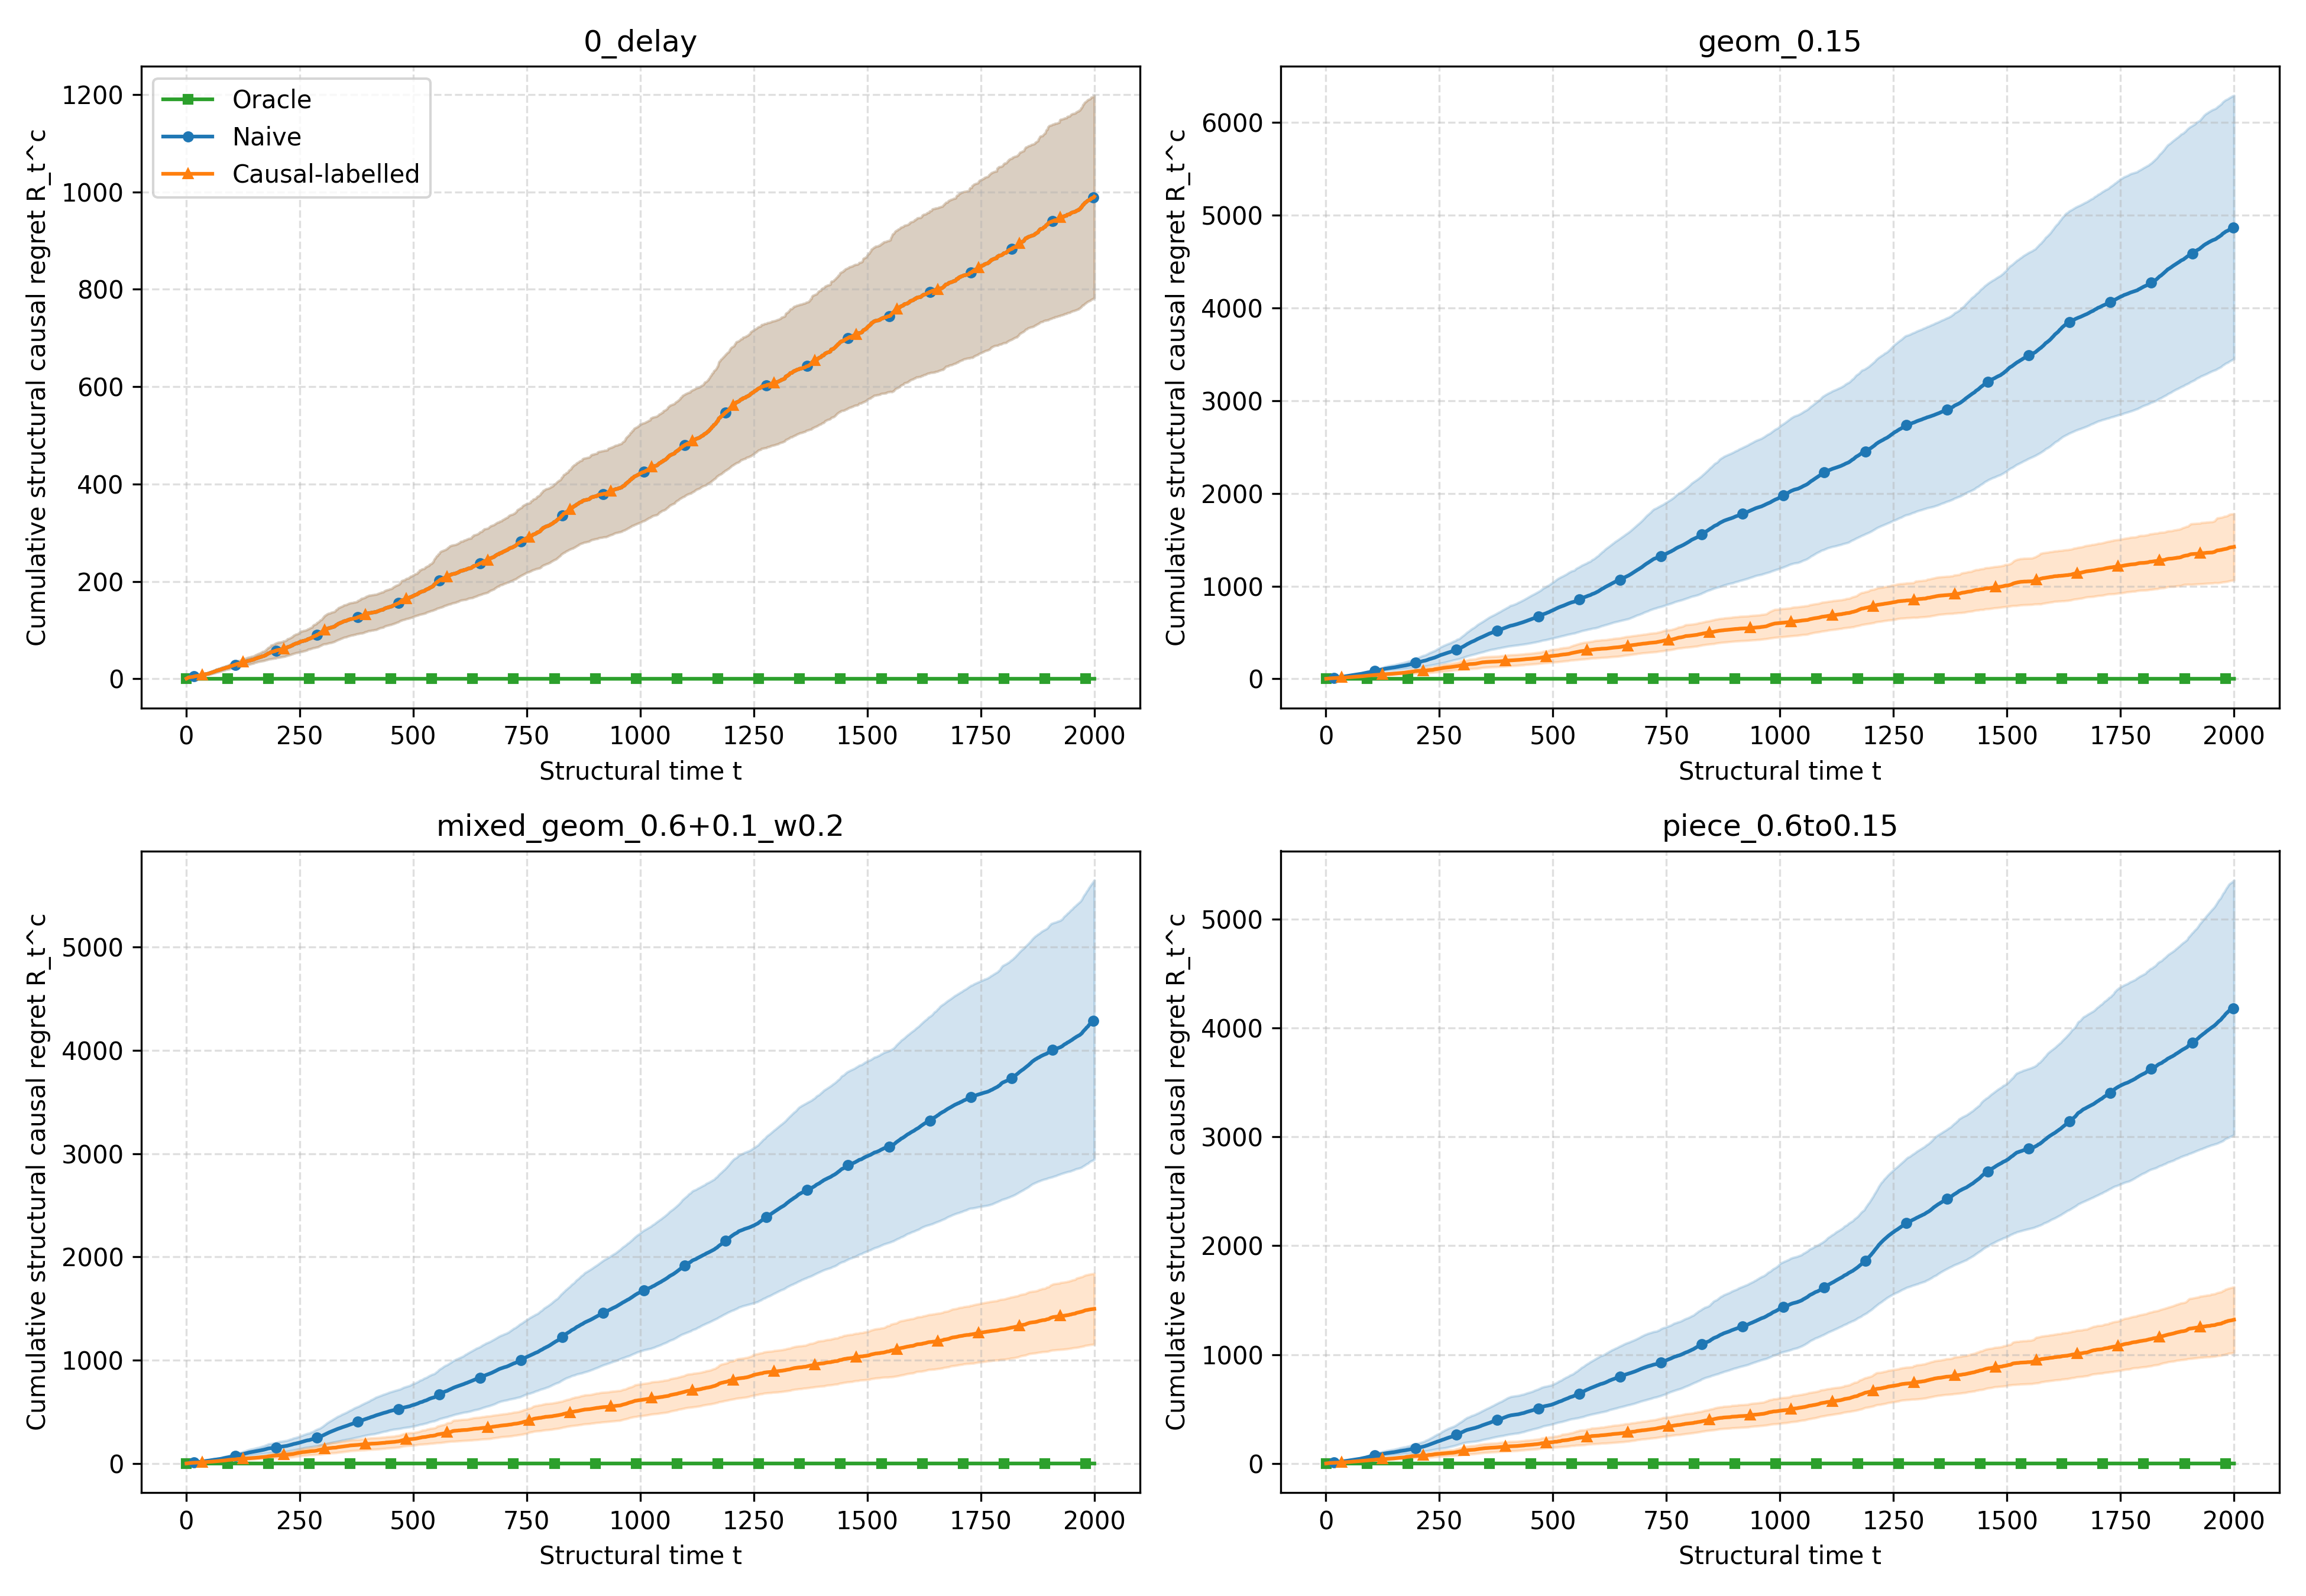

**outputs/full/figures/toy_selected_trajectories.png**

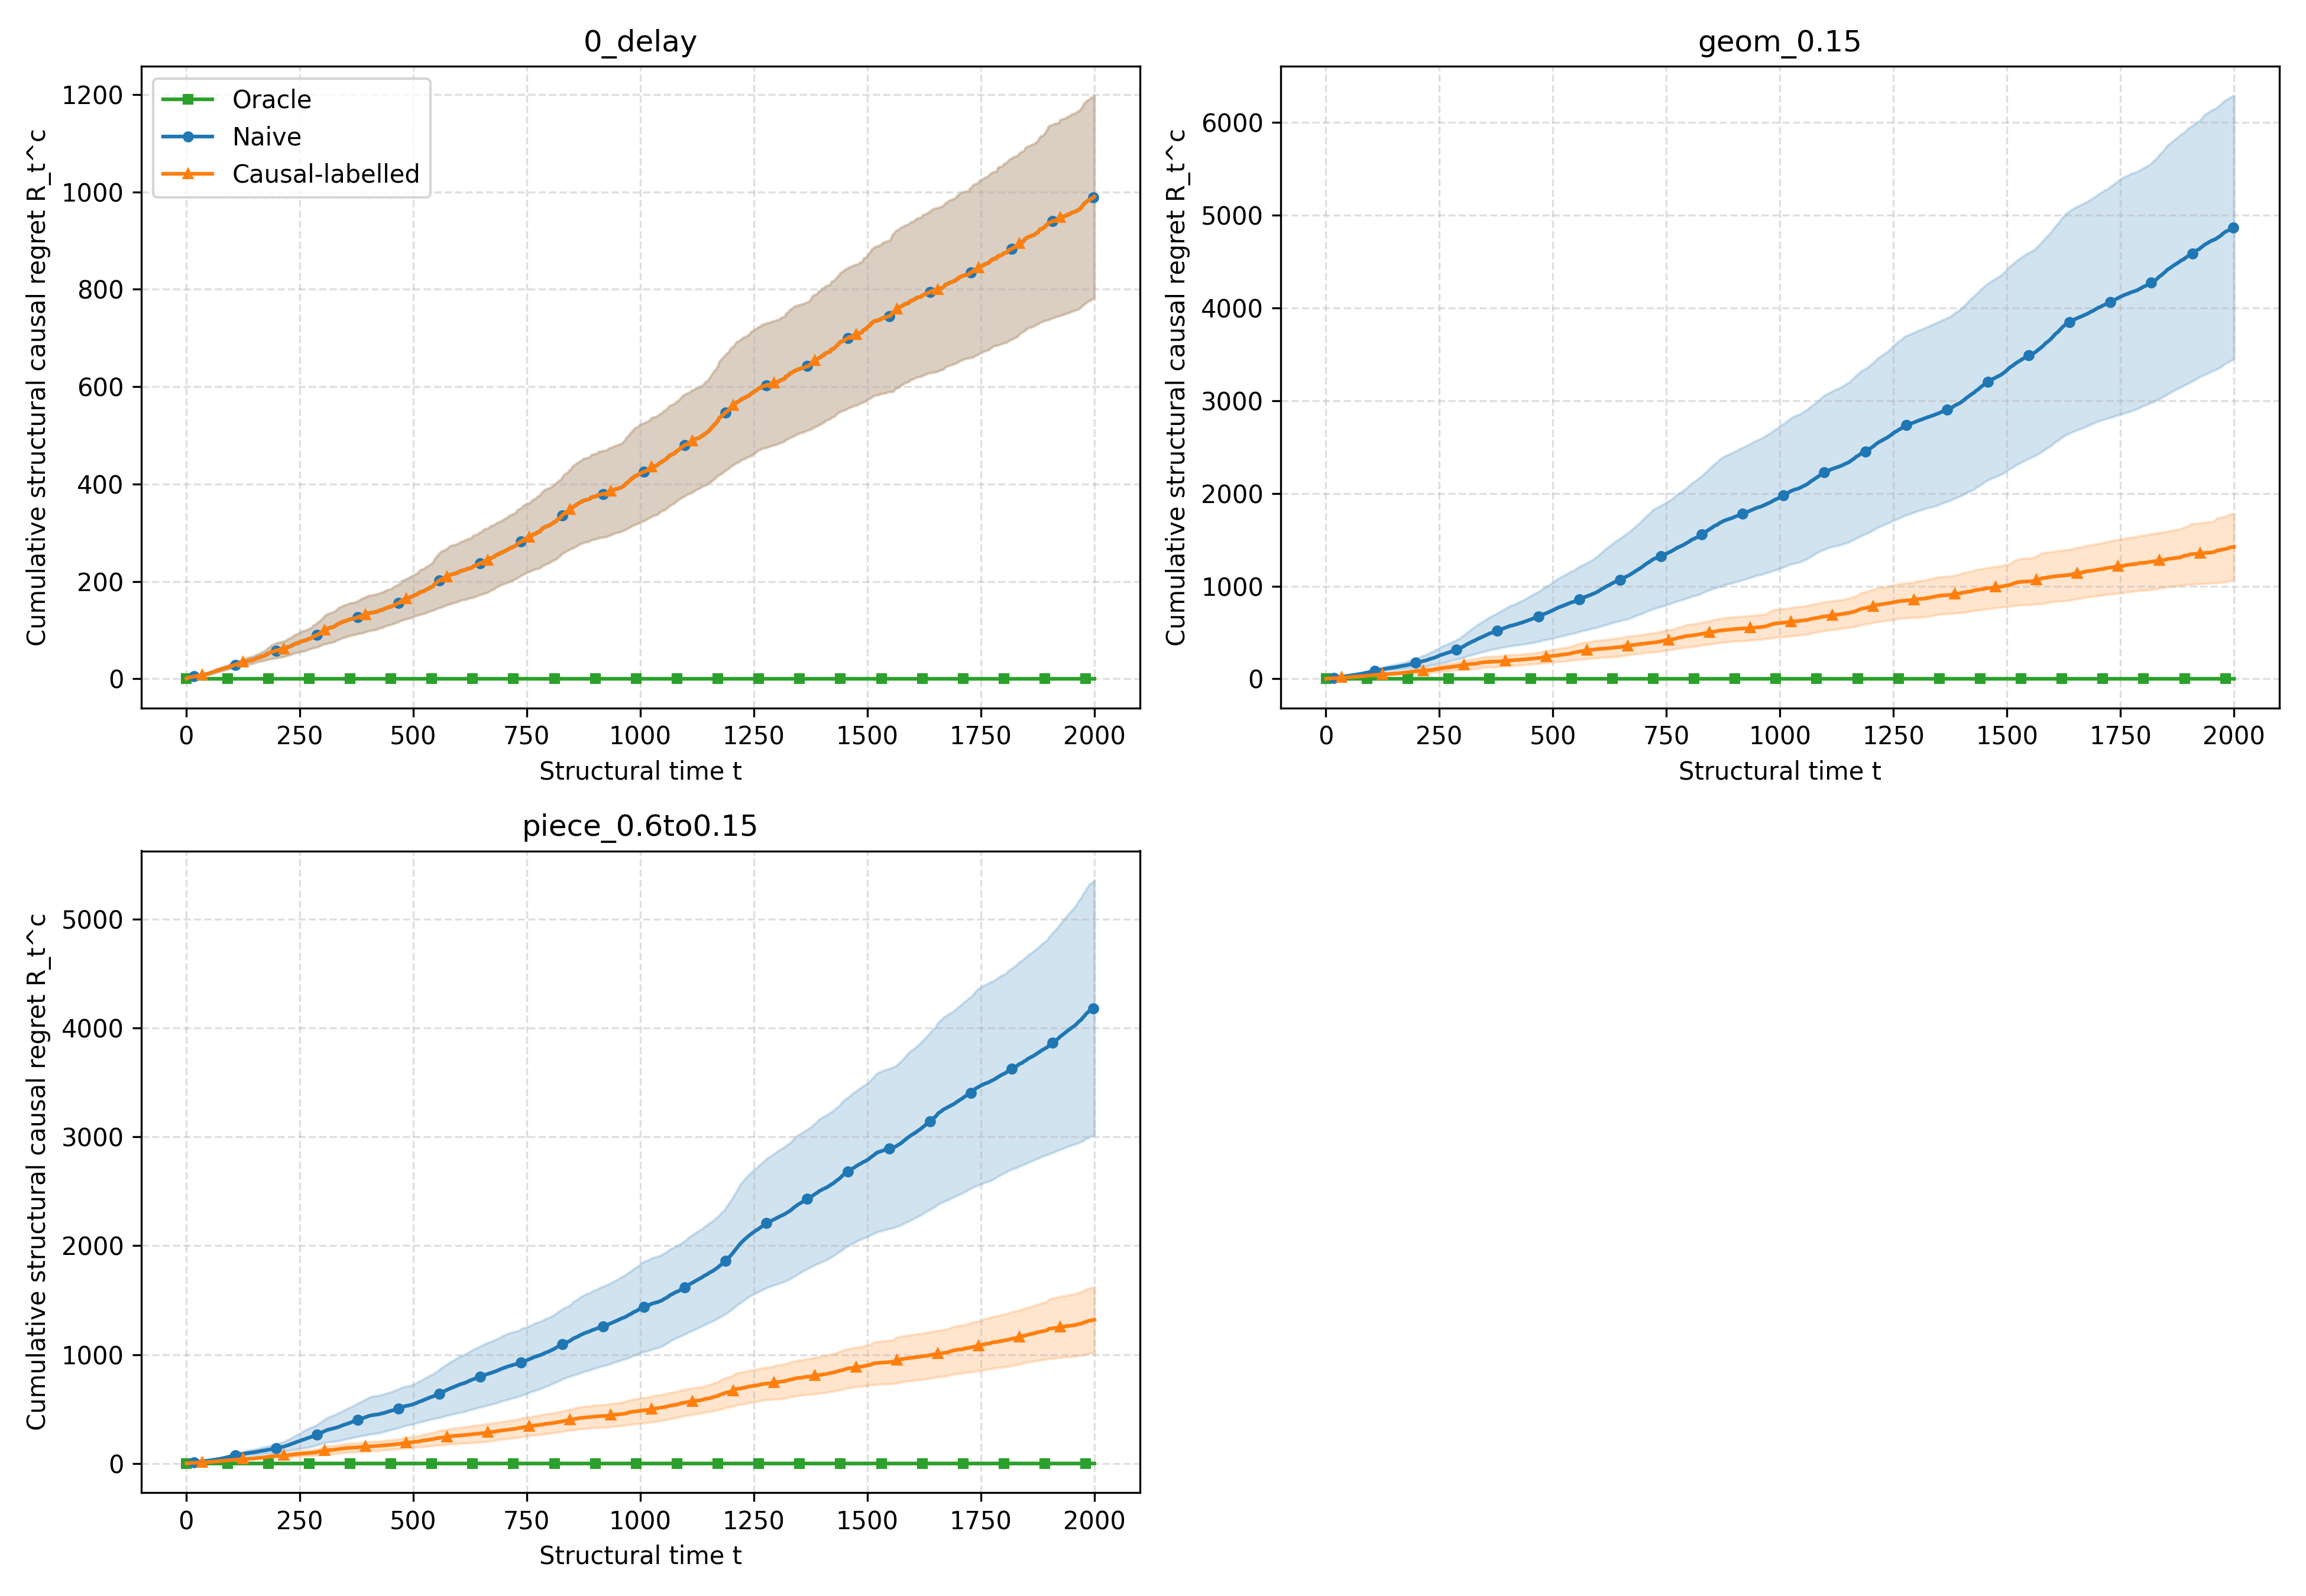

**outputs/fast/figures/toy_full_trajectories.png**

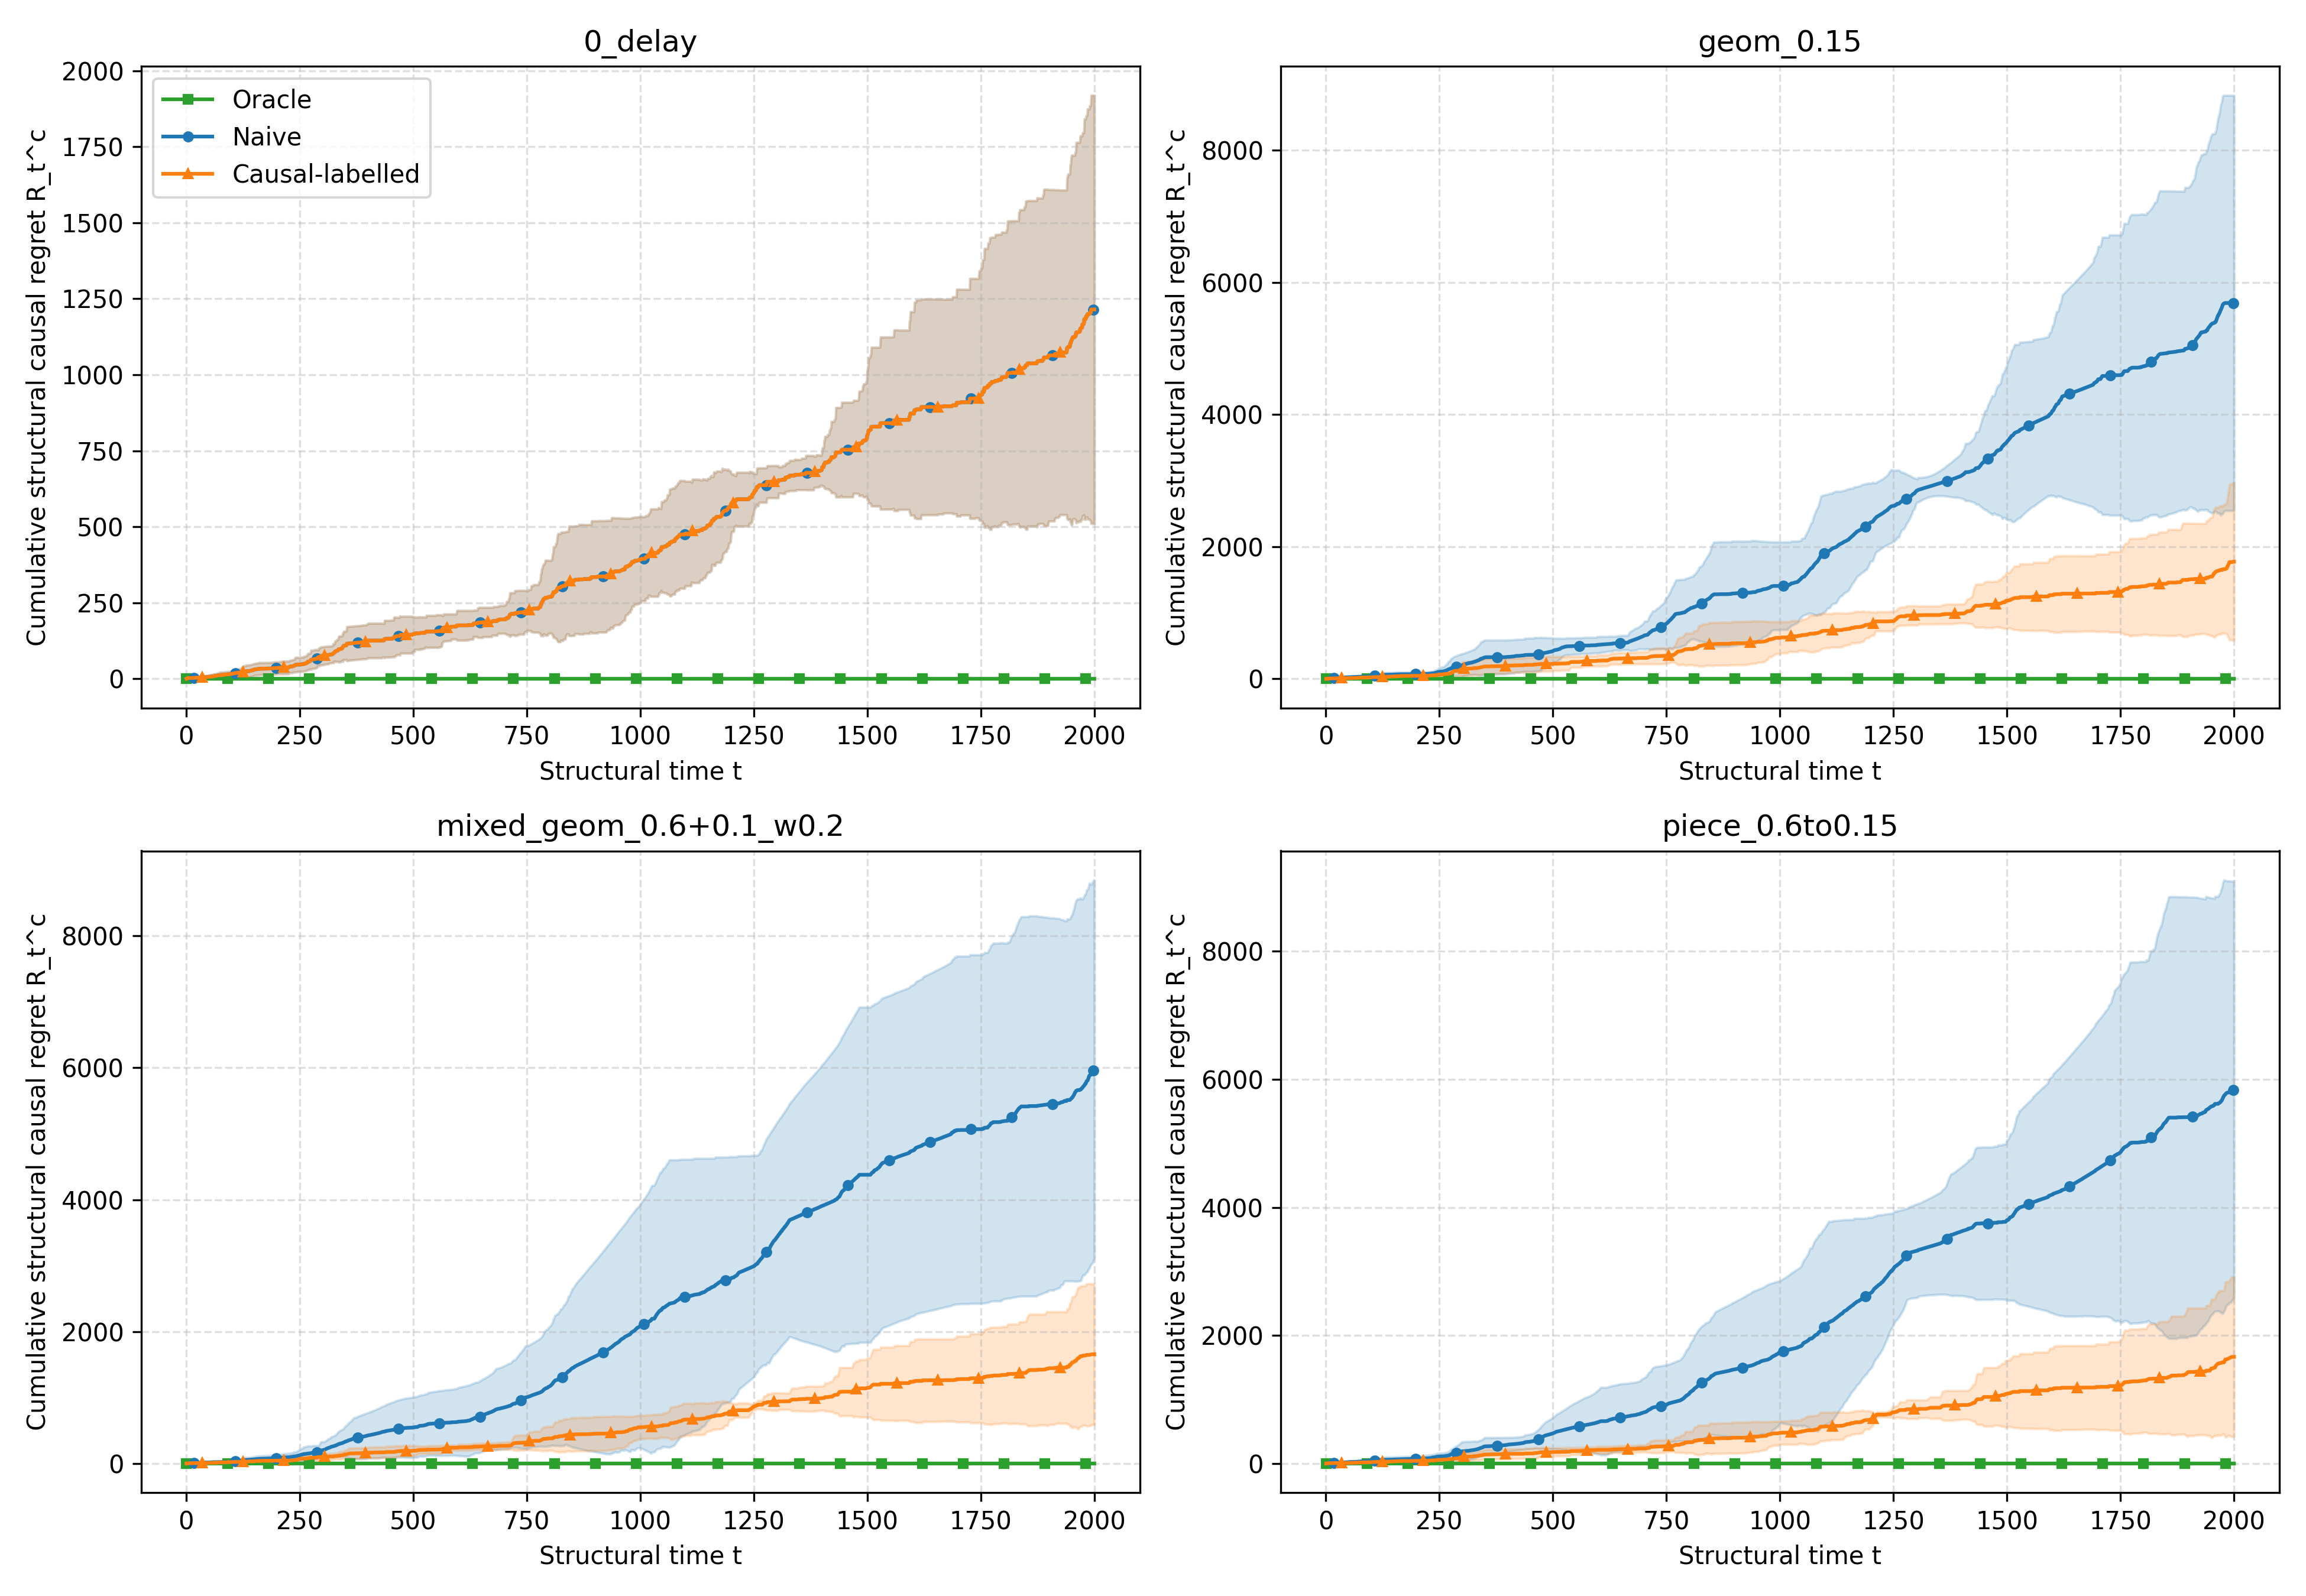

**outputs/fast/figures/toy_selected_trajectories.png**

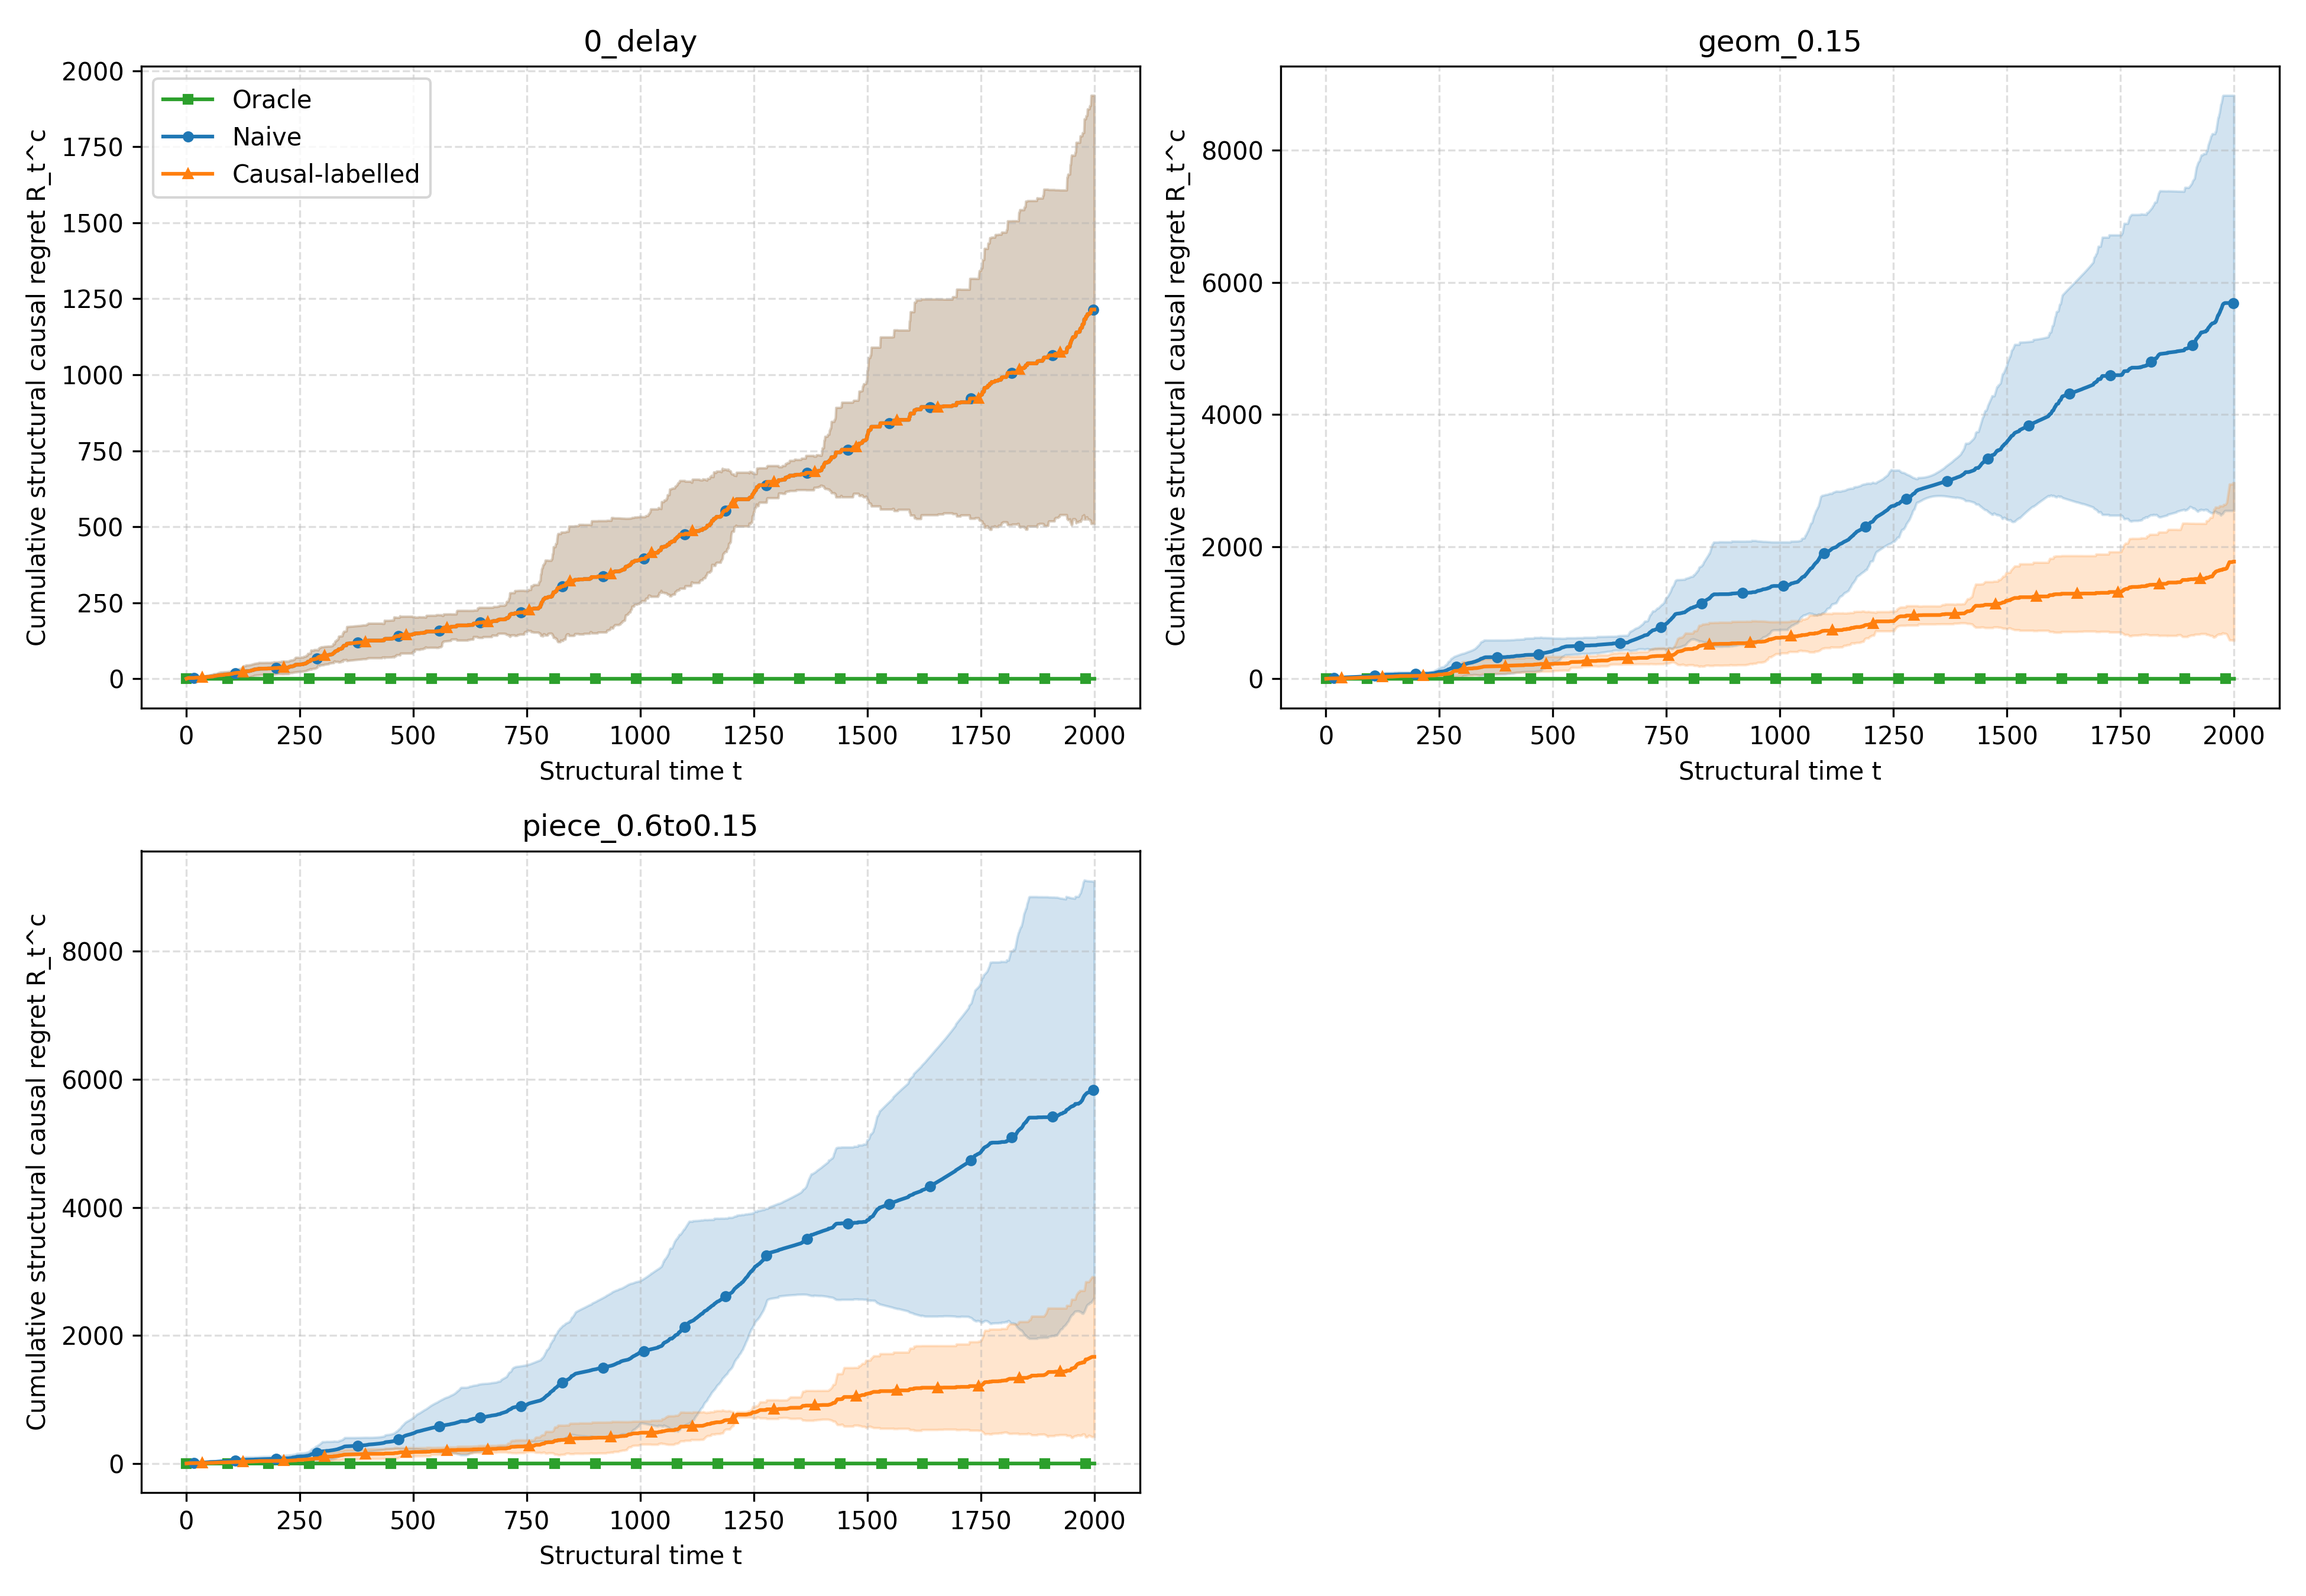

In [3]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

figures = prefer_outputs(find_files(['outputs/**/figures/**/*.png']))
display(Markdown(f'Found `{len(figures)}` PNG figure files. Showing selected embedded figures.'))
show_images(figures, limit=4)


In [4]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

logs = find_files(['runlogs/*','outputs/**/logs/*','*.log','outputs/**/checks/*'])
log_rows = [{'path': rel(p), 'size_kb': round(p.stat().st_size/1024, 1)} for p in logs[:30]]
display(Markdown(f'Found `{len(logs)}` runlog/check records.'))
display(pd.DataFrame(log_rows))
if not csvs:
    display(Markdown('Warning: no summary/table CSV detected under outputs/.'))
if not figures:
    display(Markdown('Warning: no figure PNG detected under outputs/.'))
display(Markdown('This notebook only reads existing outputs; no experiment entrypoint was executed.'))


Found `8` runlog/check records.

,path,size_kb
0,outputs/fast/logs/config_snapshot.yaml,0.3
1,outputs/fast/logs/method_registry.csv,0.4
2,outputs/fast/logs/run_manifest.csv,5.8
3,outputs/fast/logs/run_metadata.json,0.3
4,outputs/full/logs/config_snapshot.yaml,0.4
5,outputs/full/logs/method_registry.csv,0.4
6,outputs/full/logs/run_manifest.csv,57.0
7,outputs/full/logs/run_metadata.json,0.6


This notebook only reads existing outputs; no experiment entrypoint was executed.